# Part3: In-silico perturbation analysis using the trained SpiderNet model for HGSC dataset

# Package imports

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import torch
from SpiderNet.model import SpiderNet_model
import json

# Paths

In [34]:
file_savepath_main = "D:/CellFlowMap/HGSC/Results/V1/SpiderNet_Result_Mode_cell_class_selfsetdim15/"
adata_choose_path = file_savepath_main + f"adata_choose_Malignant.h5ad"
adata_list_path = file_savepath_main + f"adata_list.pkl"
SpiderNet_data_pyg_list_path = file_savepath_main + f"SpiderNet_data_pyg_list.pkl"
Factor_envir_list_path = file_savepath_main + f"Factor_envir_list.pkl"
file_savepath_model_main = file_savepath_main + f"Model/"
max_epoch = 20000
loading_LR_use_df_path = file_savepath_main + f"loading_LR_use.csv"
model_config_savepath = file_savepath_model_main + "SpiderNet_model_config.json"
LR_list_path = file_savepath_main + f"LR_list.pkl"

# Load the trained model

In [35]:
with open(model_config_savepath, "r") as f:
    model_config = json.load(f)
print(model_config)
##
model = SpiderNet_model(num_gene=int(model_config['num_gene']),
                          num_LR=int(model_config['num_LR']),
                          hidden_channels=int(model_config['hidden_channels']),
                          Factor_mode=model_config['Factor_mode'],
                          dim_intri=int(model_config['dim_intri']),
                          dim_envir=int(model_config['dim_envir']))
model.load_state_dict(torch.load(file_savepath_model_main + 'model_epoch' + str(max_epoch - 1) + '.pth'))
model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)


{'num_gene': 979, 'num_LR': 185, 'hidden_channels': 64, 'Factor_mode': 'cell_class', 'dim_intri': 7, 'dim_envir': 15}


# Load data

In [36]:
adata_choose = sc.read_h5ad(adata_choose_path)
adata_list = pd.read_pickle(adata_list_path)
SpiderNet_data_pyg_list = pd.read_pickle(SpiderNet_data_pyg_list_path)
Factor_envir_list = pd.read_pickle(Factor_envir_list_path)
loading_LR_use_df = pd.read_csv(loading_LR_use_df_path, index_col=0)
LR_list = pd.read_pickle(LR_list_path)

# Specify the sender cell type, receiver cell type, and meta-interaction of interest for in-silico perturbation

In [37]:
sender_celltype = "Fibroblast"
receiver_MC_OI = '3'
MI_OI = 'MI10'

# Get the cell barcode of Malignant cluster of interest

In [38]:
cell_barcode_MalignantOI = adata_choose.obs['barcode'][adata_choose.obs['MI_louvain'] == receiver_MC_OI].tolist()
MI_OI_numeric = int(MI_OI.replace('MI', '')) - 1

# Get the CAF gene list

In [39]:
caf_modules = {
    "myCAF": ["ACTA2", "TAGLN", "MYL9", "TPM2", "CNN1", "CALD1", "COL1A1", "COL1A2"],
    "iCAF": ["IL6", "CXCL12", "CXCL14", "LIF", "CCL2", "PTGS2"],
    "apCAF": ["HLA-DRA", "HLA-DRB1", "CD74", "CIITA"],
    "meCAF": ["COL11A1", "THBS2", "MMP11", "ITGA11", "FN1", "VCAN", "SPARC", "SULF1", "LOX", "PLOD2"],
    "periCAF": ["RGS5", "PDGFRB", "MCAM", "NOTCH3", "TAGLN"],
    "prolCAF": ["MKI67", "TOP2A", "PCNA"]
}
caf_genes_inadata = []
for module in caf_modules.values():
    for gene in module:
        if gene in adata_list[0].var_names:
            caf_genes_inadata.append(gene)
caf_genes_inadata = np.unique(caf_genes_inadata)
caf_genes_inadata_geneindex = np.where(np.isin(adata_list[0].var_names, caf_genes_inadata))[0]


# Get the tumor functional state gene list

In [40]:
functional_geneset_list_df = pd.read_csv("D:/CellFlowMap/HGSC/Data/CancerSEA_OV/functional_geneset_list_df.csv")
functional_geneset_list_df = functional_geneset_list_df.iloc[
                             np.where(np.isin(functional_geneset_list_df['Gene'], adata_list[0].var_names))[0], :]
print(np.unique(functional_geneset_list_df['GeneSet']))
functional_geneset_choose_geneindex_dict = {}
for functional_geneset_choose_term in np.unique(functional_geneset_list_df['GeneSet']):
    functional_geneset_choose = functional_geneset_list_df['Gene'].iloc[
        np.where(functional_geneset_list_df['GeneSet'] == functional_geneset_choose_term)[0]].values
    functional_geneset_choose_geneindex = np.where(np.isin(adata_list[0].var_names, functional_geneset_choose))[0]
    functional_geneset_choose_geneindex_dict[functional_geneset_choose_term] = functional_geneset_choose_geneindex
    ##Print the number of genes in each functional gene set
    print(f"{functional_geneset_choose_term}: {len(functional_geneset_choose_geneindex)} genes")
del functional_geneset_choose_term


['Angiogenesis' 'Apoptosis' 'Cell Cycle' 'Differentiation' 'EMT' 'Hypoxia'
 'Inflammation' 'Metastasis' 'Quiescence' 'Stemness']
Angiogenesis: 10 genes
Apoptosis: 2 genes
Cell Cycle: 4 genes
Differentiation: 8 genes
EMT: 2 genes
Hypoxia: 13 genes
Inflammation: 11 genes
Metastasis: 9 genes
Quiescence: 8 genes
Stemness: 5 genes


# Get the top ligand-receptor pairs from LR——loading of the MI_OI

In [41]:
# -----------------------------------------
# Step 1. Collect all ligands and receptors
# -----------------------------------------
gene_index_list = adata_choose.var.index.tolist()

# Extract unique ligand and receptor genes from LR_list
ligand_all = list({g for lr in LR_list for g in lr[0]})
receptor_all = list({g for lr in LR_list for g in lr[1]})

# Map ligands/receptors to their indices in the expression matrix
ligand_all_geneindex = [gene_index_list.index(g) for g in ligand_all if g in gene_index_list]
receptor_all_geneindex = [gene_index_list.index(g) for g in receptor_all if g in gene_index_list]

# -----------------------------------------
# Step 2. Normalize LR loading matrix
# -----------------------------------------
# Each LR column is normalized by its total loading
loading_LR_use_df_norm = loading_LR_use_df.div(loading_LR_use_df.sum(axis=0), axis=1)
loading_LR_use_df_norm_MIOI = loading_LR_use_df_norm.loc[MI_OI, :]

# Select LR pairs with strong association (>0.5)
loading_LR_use_df_norm_MIOI_sorted = loading_LR_use_df_norm_MIOI.sort_values(ascending=False)
loading_LR_use_df_norm_MIOI_sorted_choose = loading_LR_use_df_norm_MIOI_sorted[
    loading_LR_use_df_norm_MIOI_sorted > 0.5
]

# -----------------------------------------
# Step 3. Parse ligand information
# -----------------------------------------
# Extract ligand names from "ligand -> receptor" notation
ligand_top_list = [x.split(' -> ')[0] for x in loading_LR_use_df_norm_MIOI_sorted_choose.index]

# Handle multi-subunit ligands (e.g., "IL12A+IL12B")
ligand_top_list_split = [
    sub for l in ligand_top_list for sub in l.replace('(', '').replace(')', '').split('+')
]

# Identify unique ligands and their indices
ligand_top_list_split_unique = list(set(ligand_top_list_split))
ligand_top_list_split_unique_geneindex = [
    gene_index_list.index(g) for g in ligand_top_list_split_unique if g in gene_index_list
]

# Baseline ligand indices (random selection from all ligands excluding top ones)
num_topL = len(ligand_top_list_split_unique_geneindex)
ligand_top_list_split_unique_geneindex_baseline = np.random.choice(
    np.setdiff1d(ligand_all_geneindex, ligand_top_list_split_unique_geneindex),
    size=num_topL,
    replace=False
)

# -----------------------------------------
# Step 4. Parse receptor information
# -----------------------------------------
# Extract receptor names from "ligand -> receptor" notation
receptor_top_list = [x.split(' -> ')[1] for x in loading_LR_use_df_norm_MIOI_sorted_choose.index]

# Handle multi-subunit receptors (e.g., "IL2RA+IL2RB")
receptor_top_list_split = [
    sub for r in receptor_top_list for sub in r.replace('(', '').replace(')', '').split('+')
]

# Identify unique receptors and their indices
receptor_top_list_split_unique = list(set(receptor_top_list_split))
receptor_top_list_split_unique_geneindex = [
    gene_index_list.index(g) for g in receptor_top_list_split_unique if g in gene_index_list
]

# Baseline receptor indices (random selection from all receptors excluding top ones)
num_topR = len(receptor_top_list_split_unique_geneindex)
receptor_top_list_split_unique_geneindex_baseline = np.random.choice(
    np.setdiff1d(receptor_all_geneindex, receptor_top_list_split_unique_geneindex),
    size=num_topR,
    replace=False
)

# Get the predicted gene expression of the receiver cells under different in-silico perturbation conditions

In [42]:
# -----------------------------------------
# Step 1. Parameters & Initialization
# -----------------------------------------
MI_strength_threshold = 0.3

# Store reconstructed expression results
exp_recon_cur_ori_df_list = []

# Lists for storing perturbation-specific expression results
exp_recon_cur_perturb_df_MalignantOI_list, exp_recon_cur_perturb_df_Fibroblast_list = [], []
exp_recon_cur_perturb_df_MalignantOI_list_half, exp_recon_cur_perturb_df_Fibroblast_list_half = [], []
exp_recon_cur_perturb_df_MalignantOI_list_baseline, exp_recon_cur_perturb_df_Fibroblast_list_baseline = [], []


# -----------------------------------------
# Step 2. Define helper function for perturbation simulation
# -----------------------------------------
def run_model_on_perturbed_graph(graph, fibro_idx, malig_idx,
                                 ligand_idx, receptor_idx, scale=0, baseline=False):
    """
    Run model inference after perturbing ligand/receptor gene expression.
    - scale=0 → full knockdown
    - scale=0.5 → half knockdown
    - baseline=True → random baseline knockdown
    """
    g = graph.clone()

    if baseline:
        # Set ligand/receptor expression to zero (random baseline)
        g.x[fibro_idx[:, None], ligand_idx] = 0
        g.x[malig_idx[:, None], receptor_idx] = 0
    else:
        # Apply partial or full scaling to ligand/receptor genes
        g.x[fibro_idx[:, None], ligand_idx] *= scale
        g.x[malig_idx[:, None], receptor_idx] *= scale

    exp_recon, *_ = model(g)

    # Return reconstructed expression as a DataFrame
    return pd.DataFrame(
        exp_recon.detach().cpu().numpy().astype(np.float32),
        index=adata_cur.obs.index,
        columns=adata_cur.var.index
    )


# -----------------------------------------
# Step 3. Main loop across samples
# -----------------------------------------
for adata_cur, pyg_cur, Factor_envir_cur in zip(adata_list, SpiderNet_data_pyg_list, Factor_envir_list):

    pyg_cur = pyg_cur.to("cpu")
    edge_index_cur = pyg_cur.edge_index.numpy()
    celltype_cur = adata_cur.obs['cell.types'].tolist()

    # Identify MalignantOI cells and their interacting fibroblast partners
    malignant_idx = [adata_cur.obs.index.get_loc(x)
                     for x in set(cell_barcode_MalignantOI) & set(adata_cur.obs.index)]
    rel1 = np.where(np.isin(edge_index_cur[:, 1], malignant_idx))[0]
    sender_mask = np.array(celltype_cur)[edge_index_cur[rel1, 0]] == sender_celltype
    rel2 = rel1[sender_mask]

    # Select strong MI edges exceeding the predefined threshold
    strong_MI_mask = Factor_envir_cur[rel2, MI_OI_numeric] > MI_strength_threshold
    rel3 = rel2[strong_MI_mask]

    # Extract fibroblast (sender) and malignant (receiver) indices
    edge_strong = edge_index_cur[rel3, :]
    Fibroblast_idx = np.unique(edge_strong[:, 0])
    Malignant_idx = np.unique(edge_strong[:, 1])

    Fibroblast_barcode = adata_cur.obs.index[Fibroblast_idx].tolist()
    Malignant_barcode = adata_cur.obs.index[Malignant_idx].tolist()

    # -------------------------------------
    # Reconstruct original (unperturbed) expression
    # -------------------------------------
    pyg_cur = pyg_cur.to(device)
    exp_ori, *_ = model(pyg_cur)
    exp_ori_df = pd.DataFrame(
        exp_ori.detach().cpu().numpy().astype(np.float32),
        index=adata_cur.obs.index,
        columns=adata_cur.var.index
    )
    exp_recon_cur_ori_df_list.append(exp_ori_df)

    # -------------------------------------
    # Perturbation 1: Full knockdown (scale=0)
    # -------------------------------------
    exp_df = run_model_on_perturbed_graph(
        pyg_cur, Fibroblast_idx, Malignant_idx,
        ligand_top_list_split_unique_geneindex,
        receptor_top_list_split_unique_geneindex,
        scale=0
    )
    exp_recon_cur_perturb_df_MalignantOI_list.append(exp_df.loc[Malignant_barcode])
    exp_recon_cur_perturb_df_Fibroblast_list.append(exp_df.loc[Fibroblast_barcode])

    # -------------------------------------
    # Perturbation 2: Random baseline knockdown
    # -------------------------------------
    exp_df = run_model_on_perturbed_graph(
        pyg_cur, Fibroblast_idx, Malignant_idx,
        ligand_top_list_split_unique_geneindex_baseline,
        receptor_top_list_split_unique_geneindex_baseline,
        baseline=True
    )
    exp_recon_cur_perturb_df_MalignantOI_list_baseline.append(exp_df.loc[Malignant_barcode])
    exp_recon_cur_perturb_df_Fibroblast_list_baseline.append(exp_df.loc[Fibroblast_barcode])

    # -------------------------------------
    # Perturbation 3: Half knockdown (scale=0.5)
    # -------------------------------------
    exp_df = run_model_on_perturbed_graph(
        pyg_cur, Fibroblast_idx, Malignant_idx,
        ligand_top_list_split_unique_geneindex,
        receptor_top_list_split_unique_geneindex,
        scale=0.5
    )
    exp_recon_cur_perturb_df_MalignantOI_list_half.append(exp_df.loc[Malignant_barcode])
    exp_recon_cur_perturb_df_Fibroblast_list_half.append(exp_df.loc[Fibroblast_barcode])


# -----------------------------------------
# Step 4. Combine all reconstructed results
# -----------------------------------------
def concat_all(dfs):
    """Concatenate a list of DataFrames into one along rows."""
    return pd.concat(dfs, axis=0)

exp_recon_cur_ori_df_list_all = concat_all(exp_recon_cur_ori_df_list)
exp_recon_cur_perturb_df_MalignantOI_all = concat_all(exp_recon_cur_perturb_df_MalignantOI_list)
exp_recon_cur_perturb_df_Fibroblast_all = concat_all(exp_recon_cur_perturb_df_Fibroblast_list)
exp_recon_cur_perturb_df_MalignantOI_all_half = concat_all(exp_recon_cur_perturb_df_MalignantOI_list_half)
exp_recon_cur_perturb_df_Fibroblast_all_half = concat_all(exp_recon_cur_perturb_df_Fibroblast_list_half)
exp_recon_cur_perturb_df_MalignantOI_all_baseline = concat_all(exp_recon_cur_perturb_df_MalignantOI_list_baseline)
exp_recon_cur_perturb_df_Fibroblast_all_baseline = concat_all(exp_recon_cur_perturb_df_Fibroblast_list_baseline)


# -----------------------------------------
# Step 5. Extract functional gene sets and CAF scores
# -----------------------------------------
def extract_functional_subsets(df_all):
    """Extract subsets of reconstructed expression corresponding to specific functional gene sets."""
    return {k: df_all.iloc[:, v] for k, v in functional_geneset_choose_geneindex_dict.items()}

# Malignant OI functional subsets
exp_recon_cur_perturb_df_MalignantOI_all_functional_choose_dict = extract_functional_subsets(exp_recon_cur_perturb_df_MalignantOI_all)
exp_recon_cur_perturb_df_MalignantOI_all_half_functional_choose_dict = extract_functional_subsets(exp_recon_cur_perturb_df_MalignantOI_all_half)
exp_recon_cur_perturb_df_MalignantOI_all_baseline_functional_choose_dict = extract_functional_subsets(exp_recon_cur_perturb_df_MalignantOI_all_baseline)

# Fibroblast CAF scores
exp_recon_cur_perturb_df_Fibroblast_all_CAFscore = exp_recon_cur_perturb_df_Fibroblast_all.iloc[:, caf_genes_inadata_geneindex]
exp_recon_cur_perturb_df_Fibroblast_all_half_CAFscore = exp_recon_cur_perturb_df_Fibroblast_all_half.iloc[:, caf_genes_inadata_geneindex]
exp_recon_cur_perturb_df_Fibroblast_all_baseline_CAFscore = exp_recon_cur_perturb_df_Fibroblast_all_baseline.iloc[:, caf_genes_inadata_geneindex]

# Compute Log2 Fold Change (LFC) for Perturbation 3

In [43]:
LFC_perturb_list = []

def compute_LFC(exp_perturb_df, exp_ori_df, genes_idx, func_name, label):
    """Compute log2 fold-change for a given condition and functional gene set."""
    exp_ori = exp_ori_df.loc[exp_perturb_df.index, :].iloc[:, genes_idx]
    ratio = np.mean(exp_perturb_df.iloc[:, genes_idx] / exp_ori, axis=1)
    df = pd.DataFrame(np.log2(ratio), columns=['LFC'])
    df["Functional_State"] = func_name
    df["Type"] = label
    return df

# --- CAF score ---
CAF_func = 'CAF_score'
for exp_df, label in [
    (exp_recon_cur_perturb_df_Fibroblast_all, 'Perturbtop'),
    (exp_recon_cur_perturb_df_Fibroblast_all_half, 'Perturbtop_half'),
    (exp_recon_cur_perturb_df_Fibroblast_all_baseline, 'Perturbrandom')
]:
    LFC_perturb_list.append(
        compute_LFC(exp_df, exp_recon_cur_ori_df_list_all, caf_genes_inadata_geneindex, CAF_func, label)
    )

# --- Malignant functional states ---
for func_name, genes_idx in functional_geneset_choose_geneindex_dict.items():
    for exp_df, label in [
        (exp_recon_cur_perturb_df_MalignantOI_all, 'Perturbtop'),
        (exp_recon_cur_perturb_df_MalignantOI_all_half, 'Perturbtop_half'),
        (exp_recon_cur_perturb_df_MalignantOI_all_baseline, 'Perturbrandom')
    ]:
        LFC_perturb_list.append(
            compute_LFC(exp_df, exp_recon_cur_ori_df_list_all, genes_idx, func_name, label)
        )

# --- Merge & save ---
LFC_perturb_all = pd.concat(LFC_perturb_list, axis=0)
LFC_perturb_all.to_csv(file_savepath_main + 'LFC_perturb_all.csv')


# Plot results

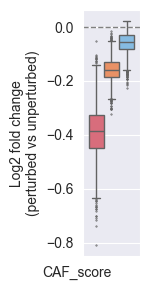

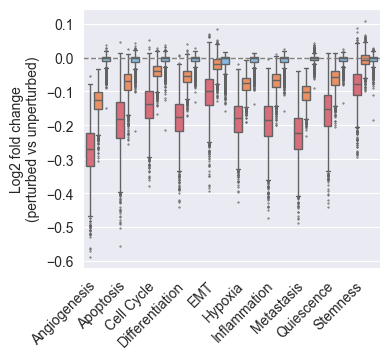

In [44]:
df_caf = LFC_perturb_all.query("Functional_State == 'CAF_score'")
df_others = LFC_perturb_all.query("Functional_State != 'CAF_score'")

palette = {"Perturbtop": "#EA5B6F", "Perturbtop_half": "#FF894F", "Perturbrandom": "#77BEF0"}

def plot_box(df, filename, figsize):
    plt.figure(figsize=figsize)
    sns.boxplot(data=df, x="Functional_State", y="LFC", hue="Type",
                dodge=True, fliersize=0.5, width=0.8, palette=palette)
    plt.axhline(0, color='gray', linestyle='--', linewidth=1)
    plt.xlabel("")
    plt.ylabel("Log2 fold change\n(perturbed vs unperturbed)", fontsize=10)
    plt.xticks(rotation=45 if figsize[0] > 2 else 0, ha='right')
    plt.legend([], [], frameon=False)
    plt.tight_layout()
    plt.savefig(file_savepath_main + filename, dpi=300)
    plt.show()
    plt.close()

# CAF score (narrow)
plot_box(df_caf, 'Perturb_LFC_boxplot_CAFscore.png', (1.6, 3))
# Others (wide)
plot_box(df_others, 'Perturb_LFC_boxplot_Others.png', (4, 3.7))
